<a href="https://colab.research.google.com/github/umang0015/AI-Tools-Usage-And-Productivity-Analysis/blob/main/Calories_Burnt_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the libraries

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Data Collection & Preprocessing

In [57]:
# loading the data from csv file in a pandas dataframe
calories = pd.read_csv('/content/drive/MyDrive/calories.csv')

In [58]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [59]:
exercise_data = pd.read_csv('/content/drive/MyDrive/exercise.csv')

In [60]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


Combining the two dataframes

In [61]:
calories_data = pd.concat([exercise_data, calories['Calories']] , axis=1)


In [62]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [63]:
# checking no of rows and columns
calories_data.shape

(15000, 9)

In [64]:
# getting some information about the data
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [65]:
# checking for missing values
calories_data.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


Data Analysis

In [66]:
# get some statistical measures of data
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Data Visualization

In [67]:
sns.set()

<Axes: xlabel='count', ylabel='Gender'>

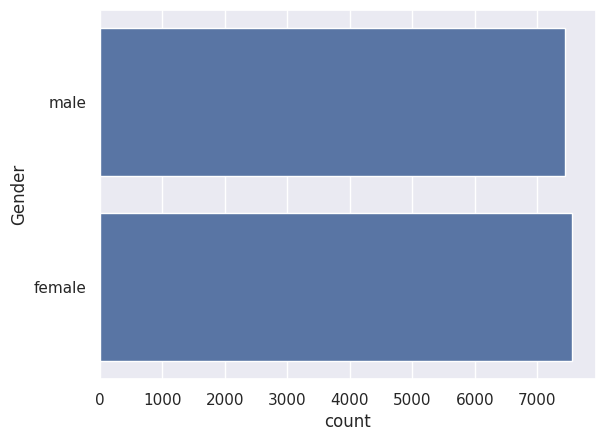

In [68]:
# plotting the gender column in count plot
sns.countplot(calories_data['Gender'])

/tmp/ipykernel_551/1432170485.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Age'])


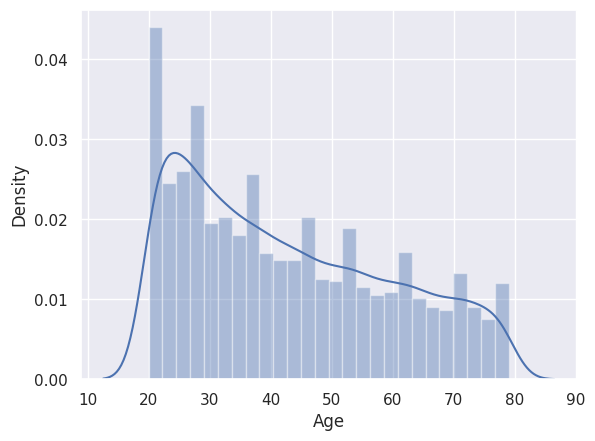

In [69]:
# finding the distribution of "Age" column
sns.distplot(calories_data['Age'])
plt.show()

/tmp/ipykernel_551/1148228354.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Height'])


<Axes: xlabel='Height', ylabel='Density'>

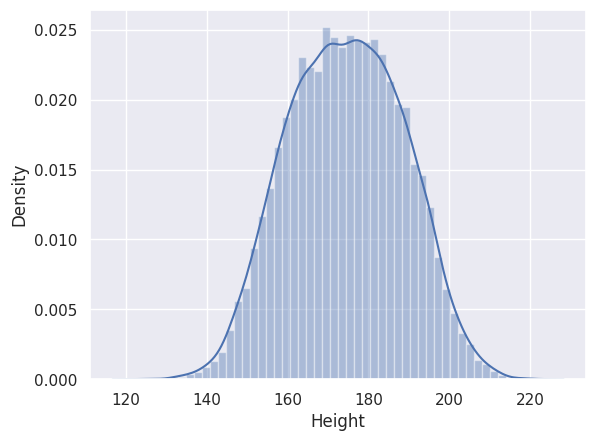

In [70]:
# finding the distribution of height column
sns.distplot(calories_data['Height'])

/tmp/ipykernel_551/2844413077.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

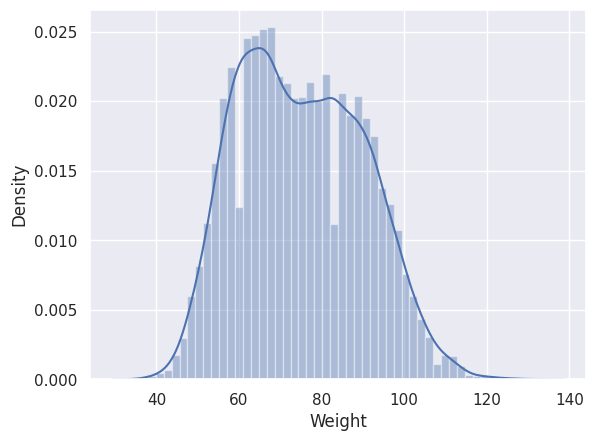

In [71]:
# finding the distribution of weight column
sns.distplot(calories_data['Weight'])

Finding the correlation btw two dataframes
1. Positive dataframe
2. Negative dataframe

### Encoding the 'Gender' column

Before calculating the correlation, we need to convert the categorical 'Gender' column into a numerical format. We'll use label encoding, mapping 'male' to 0 and 'female' to 1.

In [72]:
calories_data.replace({'Gender':{'male':0,'female':1}}, inplace=True)
calories_data.head()

/tmp/ipykernel_551/3244857472.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({'Gender':{'male':0,'female':1}}, inplace=True)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


In [73]:
# finding the correlation between dataset after encoding 'Gender'
correlation = calories_data.corr()
print(correlation)

             User_ID    Gender       Age  ...  Heart_Rate  Body_Temp  Calories
User_ID     1.000000  0.000687 -0.001827  ...   -0.000457   0.000923 -0.001661
Gender      0.000687  1.000000 -0.003222  ...   -0.011555  -0.007264 -0.022357
Age        -0.001827 -0.003222  1.000000  ...    0.010482   0.013175  0.154395
Height     -0.013520 -0.710534  0.009554  ...    0.000528   0.001200  0.017537
Weight     -0.011603 -0.783186  0.090094  ...    0.004311   0.004095  0.035481
Duration   -0.002751 -0.003440  0.013247  ...    0.852869   0.903167  0.955421
Heart_Rate -0.000457 -0.011555  0.010482  ...    1.000000   0.771529  0.897882
Body_Temp   0.000923 -0.007264  0.013175  ...    0.771529   1.000000  0.824558
Calories   -0.001661 -0.022357  0.154395  ...    0.897882   0.824558  1.000000

[9 rows x 9 columns]


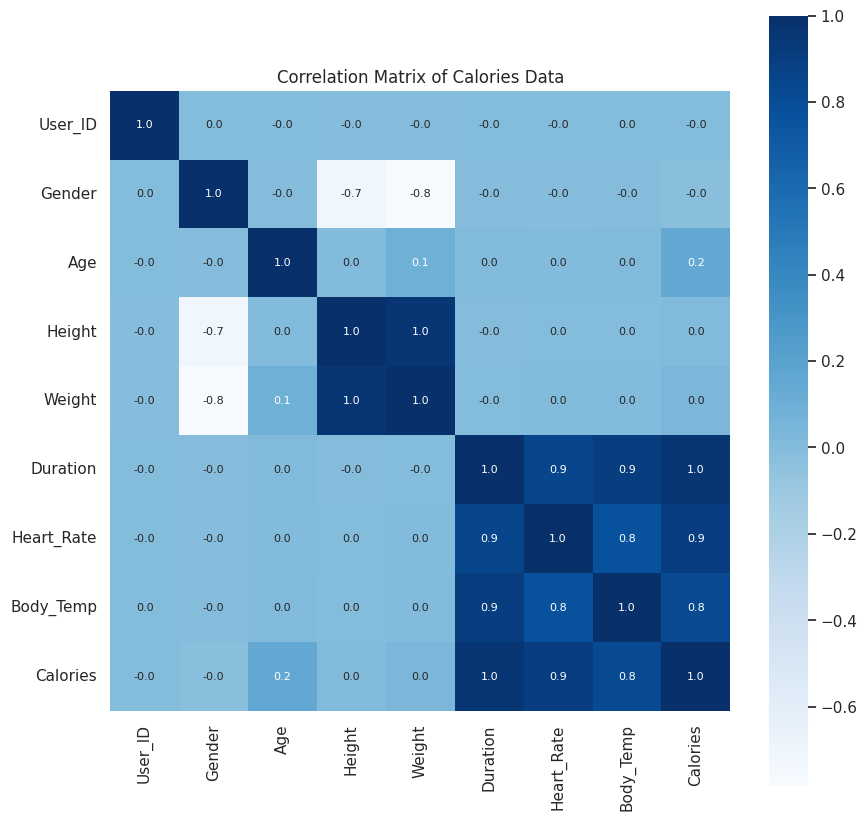

In [77]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.title('Correlation Matrix of Calories Data')
plt.show()